In [13]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
%matplotlib inline

import torch.nn.functional as F
import random

In [14]:
words = open('names.txt', 'r').read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [4]:
chars = sorted(list(set(''.join(words))))
mapp = {s:i+1 for i,s in enumerate(chars)}
mapp['.'] = 0
invmap = {i:s for s,i in mapp.items()}

In [103]:
block_size = 8
def build_dataset(words, bs):
    block_size = bs
    X,Y = [], []
    for w in words:
        #print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = mapp[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(invmap[i] for i in context), ' --> ', invmap[ix])
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

random.seed(222)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1], block_size)
Xdev, Ydev = build_dataset(words[n1:n2], block_size)
Xtst, Ytst = build_dataset(words[n2:], block_size)

In [104]:
for x,y in zip(Xtr[:20], Ytr[:20]):
    print(''.join(invmap[idx.item()] for idx in x), " --> ", invmap[y.item()])

........  -->  k
.......k  -->  a
......ka  -->  r
.....kar  -->  i
....kari  -->  s
...karis  -->  m
..karism  -->  a
.karisma  -->  .
........  -->  k
.......k  -->  r
......kr  -->  i
.....kri  -->  s
....kris  -->  t
...krist  -->  i
..kristi  -->  a
.kristia  -->  n
kristian  -->  a
ristiana  -->  .
........  -->  m
.......m  -->  i


In [ ]:
#for comments here i considered dims=12 and bs=8 and batch_size = 32

In [86]:
#1. we do not want to flatten the previous 8 characters each of 12 dimesnions into 8*12 features instead what we do is divide 8 chars into group of 2
#so we have 4 groups each with 2 char and each char have 12 dim so our dimensions from (batch_size,8, 12) ---> (batch_size, 4, 24) 
#so we made 8 features of 12 dimension into 4 features of 24 dimesnions of i think it is little better ot say 24 features of 4 dimensions instead ig
#so this si the idea we think that flatttening such a dense hting completely is wasting some informations so pair the 8 chars to 2 chars and flat them in it which makes it 4 dimensional

In [106]:
#first we have 8 chars of 12 dim each we converted to 4 groups each with 2 chars or you can say 
#8 groups of 12 dim features -> 4 groups of 24 dims features --> 4 groups of n_hidden dim features -->
#2 groups of 2*n_hidden dims features -->2 groups of n_hidden dims features --> 1 group of 2*n_hidden dimen sions features -->
#1 group of n_hidden dimensions features --> 1 group of 27 dim features and then flattened out into 27 options ([1,27] -> [27]) 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class Layer(nn.Module):
    def __init__(self, dims, bs, n_hidden, n=2):
        super().__init__()

        self.model = nn.Sequential(
            nn.Embedding(27, dims),
            
            #1. (batches,blocks,dims) --> (batches, blocks/n, n, dims)
            nn.Unflatten(1, (-1, n)),
            #2. (batches, blocks/n, n, dims) --> (batches, blocks/n, n*dims)
            nn.Flatten(start_dim=2), 

            #now dims*blocks replace with dims*n. (batches, groups, n*dims) ---> (batches, groups, n_hidden)
            #IN 2D features it appies on each group, so group_i_1to4: (n*dims -> n_hidden)
            #4,24 --> 4,256
            nn.Linear(dims*n, n_hidden, bias=False), nn.LayerNorm(n_hidden), nn.Tanh(), nn.Dropout(0.1),
            #4,256 = 2, 512
            nn.Unflatten(1, (-1, n)), nn.Flatten(start_dim=2),
            #2,512 --> 2,128
            nn.Linear(n_hidden*n, n_hidden, bias=False), nn.LayerNorm(n_hidden), nn.Tanh(), nn.Dropout(0.1),
            #2,128 = 1, 256
            nn.Unflatten(1, (-1, n)), nn.Flatten(start_dim=2),
            #1,256 --> 1,128 (this si cause we just flatened 2,128 into 1,256 now it should relation int his flattened also once
            nn.Linear(n*n_hidden, n_hidden, bias = False), nn.LayerNorm(n_hidden), nn.Tanh(), nn.Dropout(0.1),

            #1,128 --> 1,27
            nn.Linear(n_hidden, 27),
            #1,27 = 27
            nn.Flatten(start_dim=1)
        )

    def forward(self, x):
        x = self.model(x)
        return x

In [107]:
Xtr, Ytr = Xtr.to(device), Ytr.to(device)
Xdev, Ydev = Xdev.to(device), Ydev.to(device)
Xtst, Ytst = Xtst.to(device), Ytst.to(device)

In [108]:
dims = 20
n_hidden = 200
bs = block_size

layers = Layer(dims, bs, n_hidden).to(device)

with torch.no_grad():
    layers.model[-2].weight *= (0.1)

In [109]:
optimizer = torch.optim.SGD(layers.parameters(), lr=0.1, weight_decay=1e-4)

#every 95k steps multiply lr with 0.1.. so [i<95k: 0.1] and [i<190k: 0.01] amd remaining [0.001]
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size= 95000, gamma=0.1)

In [110]:
max_steps = 200000
batch_size = 100
lossi = []

for i in range(max_steps):

    #minibatch
    mb = torch.randint(0, Xtr.shape[0], (batch_size,)) # selects random 32 rows from X 
    Xb, Yb = Xtr[mb], Ytr[mb]
    
    #Forward pass
    logits = layers.forward(Xb)
    loss = F.cross_entropy(logits, Yb)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()
    
    if(i%20000 == 0):
        print(loss.item())
    lossi.append(loss.log10().item())
    
    #break 

3.2962355613708496
2.4306368827819824
2.2864487171173096
2.0524802207946777
1.9211785793304443
2.0855069160461426
2.1165130138397217
2.050436496734619
1.9257251024246216
1.7753198146820068


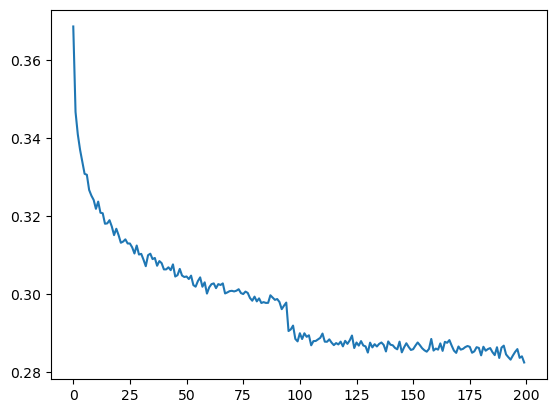

In [111]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1)) #it makes the diagram much more lookable

In [112]:
Xs = [Xtr, Xdev, Xtst]
Ys = [Ytr, Ydev, Ytst]
sets = ['train', 'val', 'test']

@torch.no_grad()
def results():
    layers.eval()  
    for n, x, y in zip(sets, Xs, Ys):
        logits = layers(x)
        loss = F.cross_entropy(logits, y)
        print(f"loss {n}: {loss.item():.4f}")

results()

loss train: 1.8341
loss val: 1.9556
loss test: 1.9483


In [113]:
for _ in range(20):
    out = []
    context = [0] * bs
    
    while True:
        x = torch.tensor([context], device=device)
        logits = layers(x)
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        
        context = context[1:] + [ix]
        out.append(ix)
        
        if ix == 0:
            break

    print(''.join(invmap[i] for i in out))

rsirian.
damae.
zagriana.
rithel.
benitie.
lucryon.
kiette.
rayani.
reon.
amarianna.
mirail.
ashlynn.
horey.
annania.
sansa.
laeryna.
kace.
ellyanne.
emine.
kyliel.


In [114]:
#below is AI code for checking how many new words are generated over existing n set ones

In [116]:
all_names = set(words)
train_names = set(words[:n1])

generated_names = []
num_samples = 100

for _ in range(num_samples):
    out = []
    context = [0] * bs
    while True:
        x = torch.tensor([context], device=device)
        logits = layers(x)
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
            
    name = ''.join(invmap[i] for i in out[:-1])  # Exclude the trailing '.'
    generated_names.append(name)

# 2. Analyze overlap and novelty
in_dataset = [n for n in generated_names if n in all_names]
in_train = [n for n in generated_names if n in train_names]
novel_names = [n for n in generated_names if n not in all_names]

print(f"Total Generated: {num_samples}")
print(f"Exact matches in names.txt: {len(in_dataset)} ({len(in_dataset)/num_samples*100:.1f}%)")
print(f"Exact matches from Train set: {len(in_train)} ({len(in_train)/num_samples*100:.1f}%)")
print(f"Brand New Inventions (Novelty): {len(novel_names)} ({len(novel_names)/num_samples*100:.1f}%)\n")

print("Sample of Brand New Inventions:")
print(novel_names[:15])

Total Generated: 100
Exact matches in names.txt: 21 (21.0%)
Exact matches from Train set: 18 (18.0%)
Brand New Inventions (Novelty): 79 (79.0%)

Sample of Brand New Inventions:
['nexemid', 'hardian', 'suwenis', 'aleee', 'yashlin', 'madde', 'nakyan', 'brayamin', 'nyeir', 'quintelle', 'camica', 'croslynn', 'giater', 'moheng', 'avonrie']
